In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os
import control as ctl

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [2]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read()).get('target')
OPTIONS

{'test': 7, 'axis': 'x'}

In [3]:
PATH = f'../files/test{OPTIONS['test']}/rolling_{OPTIONS['axis']}'
print(PATH)
print(os.listdir(PATH))

../files/test7/rolling_x
['reference', 'info.json', 'target']


In [4]:
TARGET_VAR = 'roll'
LIMITS     = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(DYNAMIC_LIMITS)
print(STATIC_LIMITS)

{'dynamic': [25, 200], 'static': [200, 999999999]}
[25, 200]
[200, 999999999]


# IMPORTANDO DADOS

In [5]:
df = pd.read_csv(f'{PATH}/target/data.csv')
df

,pitch,wz,time,wy,az,wx,e,ay,tmp,yaw,ax,roll
0,-18465,22315,2.384186e-07,-29526,-898322,-6071,0.0,-318716,46.0,359968,301898,-161407
1,-18468,-26297,8.821797e-02,29190,-900309,-29035,0.0,-320694,45.9,359967,298555,-161406
2,-18471,788,1.923132e-01,-32652,-898393,2857,0.0,-315853,46.1,359966,305663,-161405
3,-18472,-1181,2.901497e-01,6936,-896480,6915,0.0,-320703,45.9,359967,303678,-161403
4,-18471,-12629,3.944306e-01,36574,-897752,-46247,0.0,-317533,46.1,359967,301514,-161403
...,...,...,...,...,...,...,...,...,...,...,...,...
3495,-18502,15544,3.495178e+02,52779,-897381,4977,0.0,-316440,51.0,358905,305627,-161305
3496,-18500,-25141,3.496156e+02,-2845,-899800,1336,0.0,-312296,50.9,358904,308782,-161308
3497,-18500,-54,3.497143e+02,20303,-899298,33231,0.0,-312794,51.0,358903,300695,-161308
3498,-18501,122,3.498202e+02,-22021,-902863,15968,0.0,-318536,50.9,358903,306297,-161311


- Convertendo pra radianos

In [6]:
def convertAxis(df):
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df


df = convertAxis(df)
df.head()

,pitch,wz,time,wy,az,wx,e,ay,tmp,yaw,ax,roll
0,-18.465,0.22315,2.384186e-07,-0.29526,-8.809529,-0.06071,0.0,-3.125536,46.0,359.968,2.960608,-161.407
1,-18.468,-0.26297,8.821797e-02,0.29190,-8.829015,-0.29035,0.0,-3.144934,45.9,359.967,2.927824,-161.406
2,-18.471,0.00788,1.923132e-01,-0.32652,-8.810226,0.02857,0.0,-3.097460,46.1,359.966,2.997530,-161.405
3,-18.472,-0.01181,2.901497e-01,0.06936,-8.791466,0.06915,0.0,-3.145022,45.9,359.967,2.978064,-161.403
4,-18.471,-0.12629,3.944306e-01,0.36574,-8.803940,-0.46247,0.0,-3.113935,46.1,359.967,2.956842,-161.403


- Formatando as colunas pra ficar igual a de referência

In [7]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

df = switchColumns(df, 'roll', 'pitch')
df = switchColumns(df, 'wy', 'wz')
df = switchColumns(df, 'ay', 'az')

df['wy'] = -df['wy']
df['pitch'] = -df['pitch']

df.head()

,pitch,wz,time,wy,az,wx,e,ay,tmp,yaw,ax,roll
0,161.407,-0.29526,2.384186e-07,-0.22315,-3.125536,-0.06071,0.0,-8.809529,46.0,359.968,2.960608,-18.465
1,161.406,0.29190,8.821797e-02,0.26297,-3.144934,-0.29035,0.0,-8.829015,45.9,359.967,2.927824,-18.468
2,161.405,-0.32652,1.923132e-01,-0.00788,-3.097460,0.02857,0.0,-8.810226,46.1,359.966,2.997530,-18.471
3,161.403,0.06936,2.901497e-01,0.01181,-3.145022,0.06915,0.0,-8.791466,45.9,359.967,2.978064,-18.472
4,161.403,0.36574,3.944306e-01,0.12629,-3.113935,-0.46247,0.0,-8.803940,46.1,359.967,2.956842,-18.471


In [8]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,pitch,wz,time,wy,az,wx,e,ay,tmp,yaw,ax,roll


# VISUALIZAÇÃO DE VARIÁVEIS

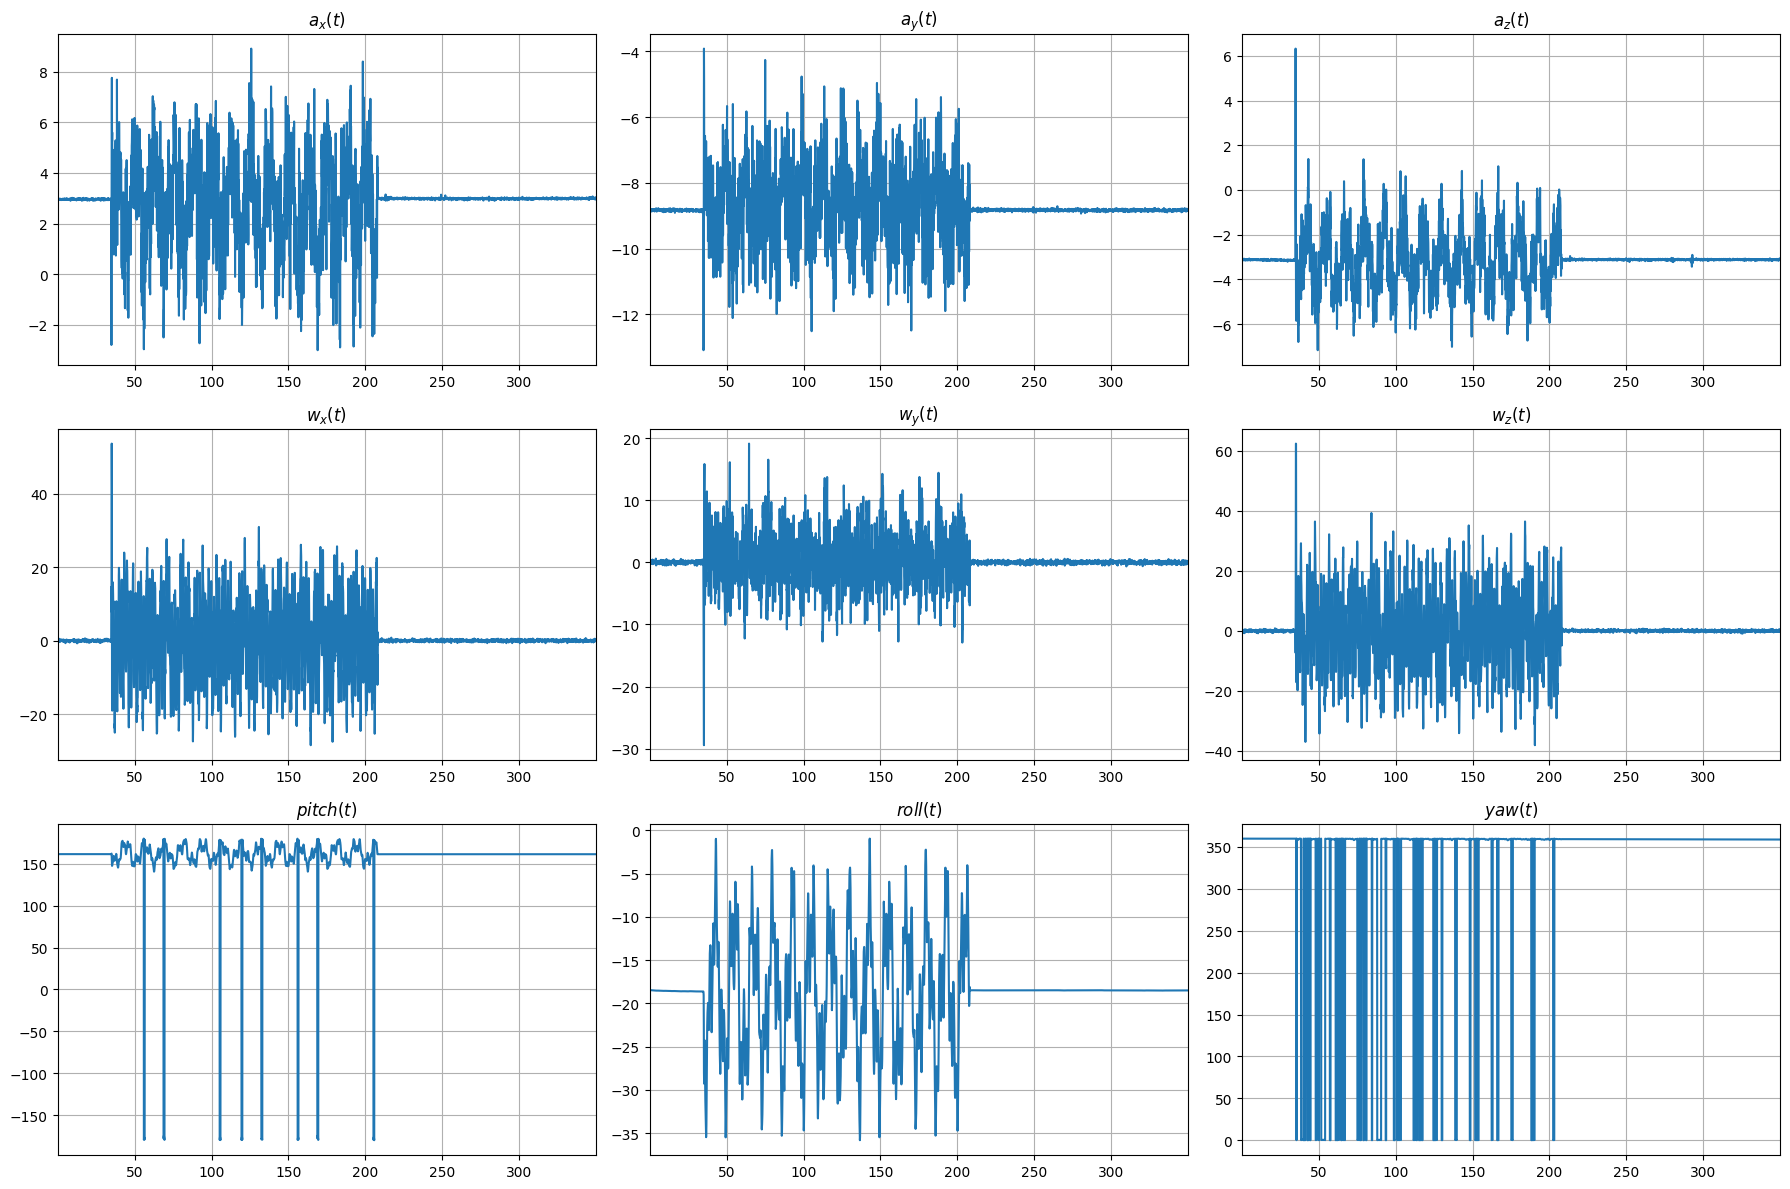

In [9]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = (t_max - t_min)
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

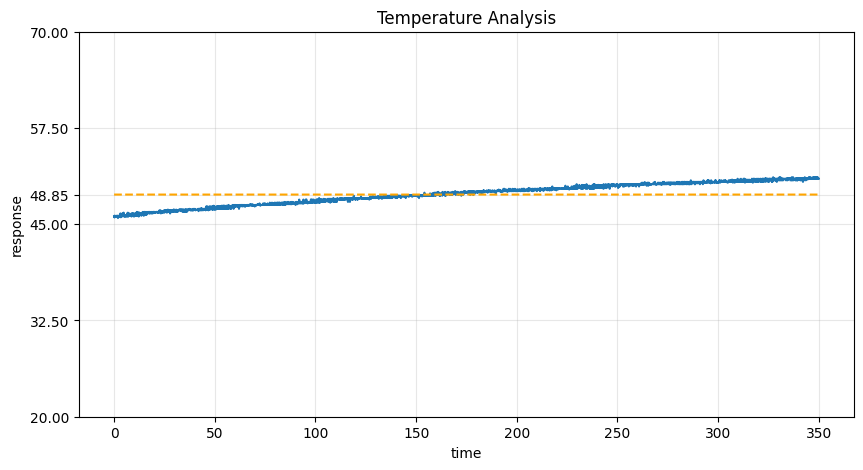

In [10]:
time = df.time.values
temp = df.tmp.values[:-100].mean()

plt.figure(figsize=(10, 5))
plt.plot(time, df.tmp)
plt.plot(time, temp*np.ones_like(time), '--', color='orange')
plt.grid(alpha=0.3); plt.xlabel('time'); plt.ylabel('response')
plt.yticks(list(np.linspace(20, 70, 5)) + [temp])
plt.title('Temperature Analysis')
plt.show()

# AMOSTRAGEM

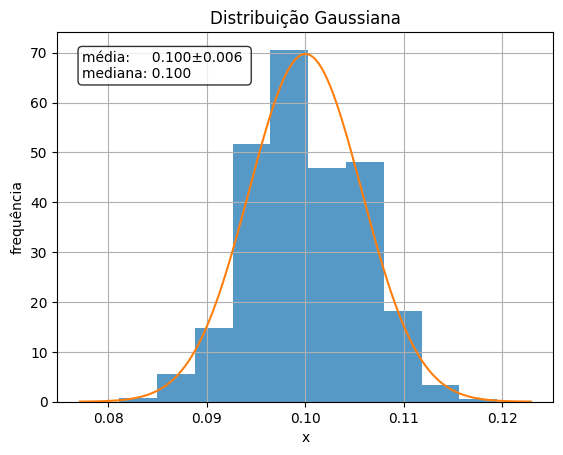

,time,pitch,wz,wy,az,wx,e,ay,tmp,yaw,ax,roll
0,0.0,161.407,-0.29526,-0.22315,-3.125536,-0.06071,0.0,-8.809529,46.0,359.968,2.960608,-18.465
1,0.1,161.406,0.29190,0.26297,-3.144934,-0.29035,0.0,-8.829015,45.9,359.967,2.927824,-18.468
2,0.2,161.405,-0.32652,-0.00788,-3.097460,0.02857,0.0,-8.810226,46.1,359.966,2.997530,-18.471
3,0.3,161.403,0.06936,0.01181,-3.145022,0.06915,0.0,-8.791466,45.9,359.967,2.978064,-18.472
4,0.4,161.403,0.36574,0.12629,-3.113935,-0.46247,0.0,-8.803940,46.1,359.967,2.956842,-18.471
...,...,...,...,...,...,...,...,...,...,...,...,...
3496,349.6,161.305,0.52779,-0.15544,-3.103216,0.04977,0.0,-8.800301,51.0,358.905,2.997177,-18.502
3497,349.7,161.308,-0.02845,0.25141,-3.062578,0.01336,0.0,-8.824024,50.9,358.904,3.028117,-18.500
3498,349.8,161.308,0.20303,0.00054,-3.067461,0.33231,0.0,-8.819101,51.0,358.903,2.948811,-18.500
3499,349.9,161.311,-0.22021,-0.00122,-3.123771,0.15968,0.0,-8.854061,50.9,358.903,3.003747,-18.501


In [11]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
df

# FILTRAGEM

In [12]:
class FrequencyAnalyzer:
    def __init__(self, xData, yData):
        self.xData = np.asarray(xData)
        self.yData = np.asarray(yData)
        
        self.dt = np.mean(np.diff(self.xData))
        self.nSamples = len(self.yData)
        
        self.yFreq = None
        self.yMag  = None

    def update(self):
        fftResult  = np.fft.fft(self.yData)
        freqs      = np.fft.fftfreq(self.nSamples, self.dt)
        self.yFreq = np.fft.fftshift(freqs)
        self.yMag  = np.fft.fftshift(np.abs(fftResult)) / self.nSamples

    def plot(self, xLim=None, yLim=None, Fc=None):
        self.update()

        plt.plot(self.yFreq, self.yMag, label='blue', color='red', alpha=0.5)

        if Fc is not None:
            yMagRestricted = self.yMag.copy()
            allowed = (np.abs(self.yFreq) <= Fc)
            yMagRestricted[~allowed] = 0
            plt.plot(self.yFreq, yMagRestricted, label=f'Fc={Fc}', color='blue')
        
        plt.xlabel('frequency')
        plt.ylabel('amplitude')
        plt.grid(alpha=0.3)
        
        if xLim: plt.xlim(xLim)
        if yLim: plt.ylim(yLim)
        plt.legend()


class LowPassFilter:
    def __init__(self, Fc, dt):
        self.dt = dt
        self.Fc = Fc
        
        Wc = (2 * np.pi * Fc) 
        s  = ctl.TransferFunction.s
        
        H   = Wc / (s + Wc)
        H_z = ctl.c2d(H, dt, method='tustin')
        
        self.num, self.den = self.getFraction(H_z)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))

    def getFraction(self, G_z):
        num, den = ctl.tfdata(G_z)
        num = np.squeeze(num)
        den = np.squeeze(den)

        num = num / den[0]
        den = den / den[0]
        return num.tolist(), den.tolist()

    def compute(self):
        out = 0.0
        for i in range(len(self.num)):
            out += self.Xn[i] * self.num[i]
        
        for i in range(1, len(self.den)):
            out -= self.Yn[i] * self.den[i]

        return out

    def update(self, inputValue):
        for n in range(len(self.num)-1, 0, -1):
            self.Xn[n] = self.Xn[n-1]

        for n in range(len(self.den)-1, 0, -1):
            self.Yn[n] = self.Yn[n-1]
        
        self.Xn[0] = inputValue
        self.Yn[0] = self.compute()
        return self.Yn[0] if self.Fc > 0 else inputValue

    def apply(self, yData):
        yData = np.array(yData)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))
        for i in range(100): self.update(yData[0])
        return np.array([self.update(val) for val in yData])

    def test(self, df, var, xLim, yLim, limits=(0, 100)):
        plt.figure(figsize=(17, 5))
        plt.subplot(1, 2, 1)
        print('testing', var)
        FrequencyAnalyzer(df.time, df[var]).plot(xLim, yLim, Fc=Fc)

        plt.subplot(1, 2, 2)
        target = df.loc[(df.time >= limits[0]) & (df.time <= limits[1])]
        plt.plot(target.time, target[var], label='values')
        plt.plot(target.time, self.apply(target[var]), label=f'Fc={Fc}', linewidth=2)
        plt.grid(alpha=0.3); plt.legend()
        plt.xlabel('time'); plt.ylabel('values')
        plt.show()
        df[var] = self.apply(df[var])
        return df.copy()


APPLY_FILTERS = False

if APPLY_FILTERS:
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'ax', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'ay', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))
    df = LowPassFilter(Fc=1.5, dt=dt).test(df, 'az', xLim=(-5, 5), yLim=(0, 0.01), limits=(50, 70))

    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wx', xLim=(-5, 5), yLim=(0, 0.1), limits=(50, 70))
    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wy', xLim=(-5, 5), yLim=(0, 0.1),  limits=(50, 70))
    df = LowPassFilter(Fc=1.2, dt=dt).test(df, 'wz', xLim=(-5, 5), yLim=(0, 0.1), limits=(50, 70))

# SEPARAÇÃO DE TABELAS
- Juntando Amostragem pelos limites definidos

In [13]:
df_static  = df.loc[(df.time >= STATIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])].copy()
df_dynamic = df.loc[(df.time > DYNAMIC_LIMITS[0]) & (df.time <= DYNAMIC_LIMITS[1])].copy() 

df_dynamic['static'] = False
df_static['static']  = True

df_dynamic.loc[:, 'time'] = (df_dynamic.time - df_dynamic.time.values[0])
df_static.loc[:, 'time']  = (df_static.time  - df_static.time.values[0])  + df_dynamic.time.values[-1]

df = pd.concat([df_dynamic, df_static], axis=0, ignore_index=True)
df

,time,pitch,wz,wy,az,wx,e,ay,tmp,yaw,ax,roll,static
0,0.0,161.399,-0.28498,0.02387,-3.098666,-0.41792,0.0,-8.810932,46.5,359.904,2.970150,-18.605,False
1,0.1,161.399,-0.29589,0.11780,-3.159712,-0.18404,0.0,-8.850933,46.6,359.905,2.973337,-18.604,False
2,0.2,161.398,-0.10334,0.07233,-3.177168,0.17382,0.0,-8.815835,46.8,359.903,2.926363,-18.604,False
3,0.3,161.398,0.33386,0.02622,-3.140011,-0.10057,0.0,-8.793250,46.8,359.902,2.931374,-18.603,False
4,0.4,161.398,0.47356,0.12890,-3.119544,-0.10119,0.0,-8.823877,46.6,359.902,2.953753,-18.603,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3246,324.5,161.305,0.52779,-0.15544,-3.103216,0.04977,0.0,-8.800301,51.0,358.905,2.997177,-18.502,True
3247,324.6,161.308,-0.02845,0.25141,-3.062578,0.01336,0.0,-8.824024,50.9,358.904,3.028117,-18.500,True
3248,324.7,161.308,0.20303,0.00054,-3.067461,0.33231,0.0,-8.819101,51.0,358.903,2.948811,-18.500,True
3249,324.8,161.311,-0.22021,-0.00122,-3.123771,0.15968,0.0,-8.854061,50.9,358.903,3.003747,-18.501,True


# FILTRANDO POR VARIAVEL

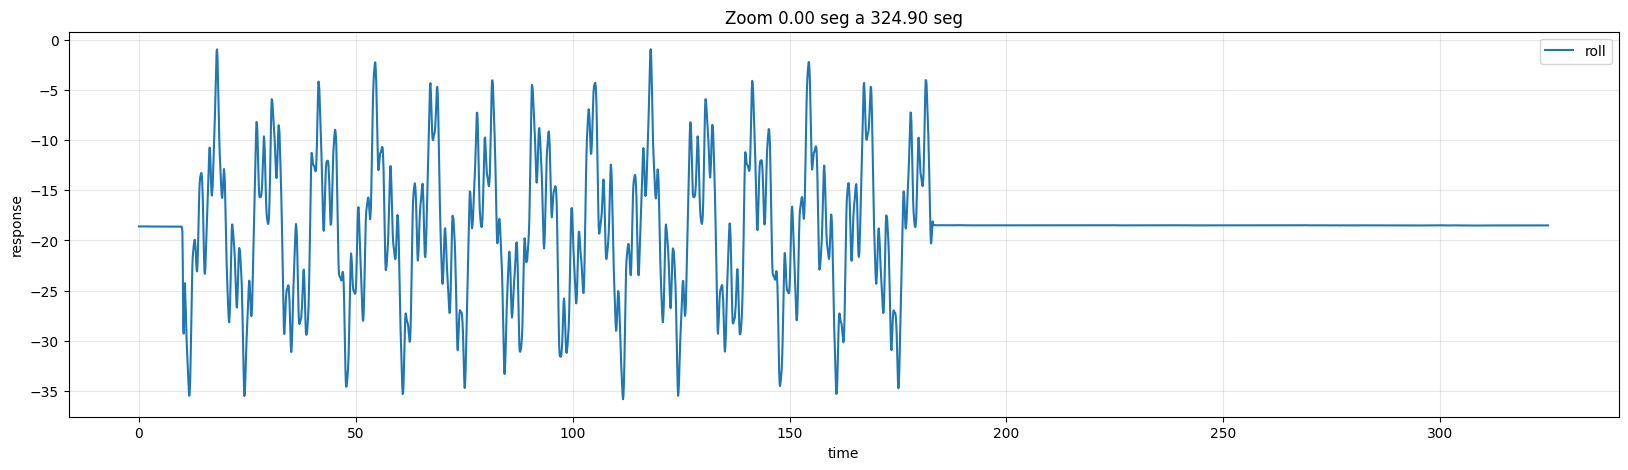

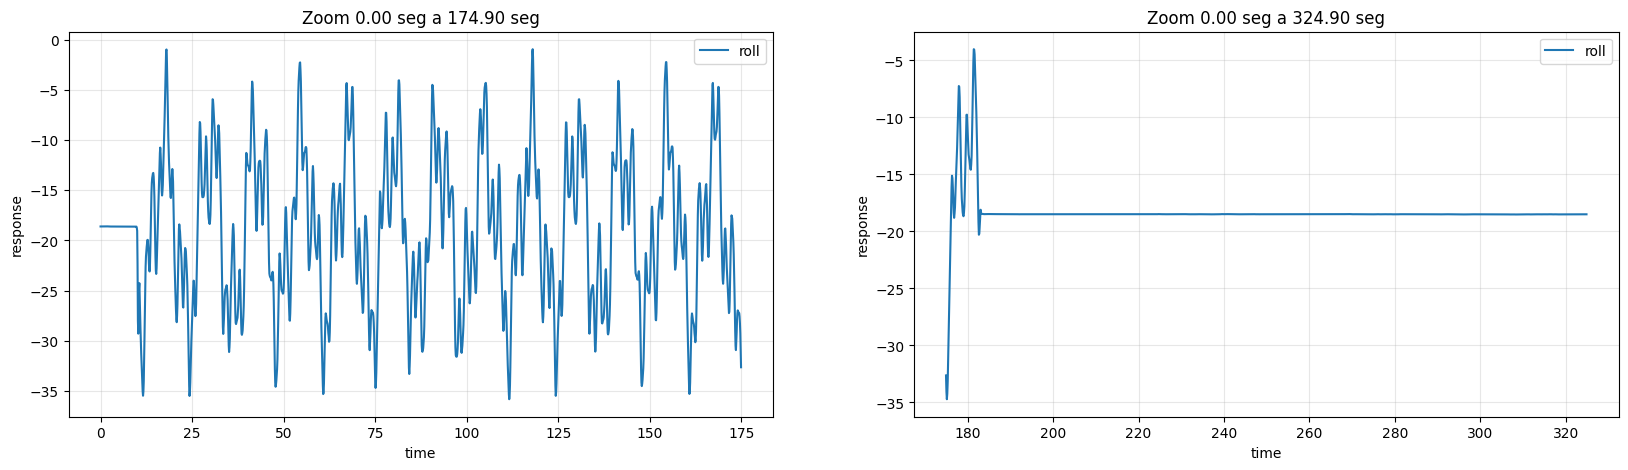

In [14]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plotViews(df, limits=(0, 1))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_static, limits=(0, 1))

# SALVANDO DADOS

In [15]:
df = df.rename(columns={col: 'target_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,target_pitch,target_wz,target_wy,target_az,target_wx,target_e,target_ay,target_tmp,target_yaw,target_ax,target_roll,static
0,0.0,161.399,-0.28498,0.02387,-3.098666,-0.41792,0.0,-8.810932,46.5,359.904,2.970150,-18.605,False
1,0.1,161.399,-0.29589,0.11780,-3.159712,-0.18404,0.0,-8.850933,46.6,359.905,2.973337,-18.604,False
2,0.2,161.398,-0.10334,0.07233,-3.177168,0.17382,0.0,-8.815835,46.8,359.903,2.926363,-18.604,False
3,0.3,161.398,0.33386,0.02622,-3.140011,-0.10057,0.0,-8.793250,46.8,359.902,2.931374,-18.603,False
4,0.4,161.398,0.47356,0.12890,-3.119544,-0.10119,0.0,-8.823877,46.6,359.902,2.953753,-18.603,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3246,324.5,161.305,0.52779,-0.15544,-3.103216,0.04977,0.0,-8.800301,51.0,358.905,2.997177,-18.502,True
3247,324.6,161.308,-0.02845,0.25141,-3.062578,0.01336,0.0,-8.824024,50.9,358.904,3.028117,-18.500,True
3248,324.7,161.308,0.20303,0.00054,-3.067461,0.33231,0.0,-8.819101,51.0,358.903,2.948811,-18.500,True
3249,324.8,161.311,-0.22021,-0.00122,-3.123771,0.15968,0.0,-8.854061,50.9,358.903,3.003747,-18.501,True


In [16]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)